In [6]:
import pandas as pd
import random
import os
from pyecharts import options as opts
from pyecharts.charts import Graph

# ================= ⚡ 配置区 =================
TRIPLETS_FILE = 'aibl_knowledge_triplets.csv'
OUTPUT_FILE = "aibl_kg_visualization.html"

# 🎨 颜色方案 (高对比度)
COLORS = {
    "Patient":         "#c23531",   # 🔴 病人 (红)
    "Gene":            "#52c41a",   # 🟢 基因 (绿) - 核心桥梁
    "PrimeKG_Disease": "#e6a23c",   # 🟠 疾病 (橙) - 知识大海
    "PrimeKG_Gene":    "#fdd835",   # 🟡 基因 (黄)
    "Symptom":         "#2f4554",   # 🔵 症状
    "Attribute":       "#61a0a8",   # 💠 属性 (青)
    "Other":           "#d48265"    # 🟤 其他
}

# ================= 1. 核心工具函数 =================

def get_node_category(node_name):
    """根据节点名字判断类别"""
    if node_name.startswith("Patient:"): return "Patient"
    if node_name.startswith("Gene:"):    return "Gene"
    if node_name.startswith("Concept:") or node_name.startswith("Test:"): return "Attribute"
    
    if node_name.startswith("PrimeKG:"): 
        real_name = node_name.split(":", 1)[1]
        # 简单规则：全大写且短的是基因(如INS)，否则是疾病/表型
        if " " not in real_name and real_name.isupper() and len(real_name) < 10:
            return "PrimeKG_Gene"
        else:
            return "PrimeKG_Disease"
            
    return "Other"

def print_statistics(nodes):
    """📊 在控制台打印详细的节点统计信息"""
    stats = {}
    for node in nodes:
        cat = get_node_category(node)
        stats[cat] = stats.get(cat, 0) + 1
    
    print("\n" + "="*40)
    print(f"📊 图谱节点数统计 (共 {len(nodes)} 个节点)")
    print("="*40)
    
    # 按数量降序排列
    for cat, count in sorted(stats.items(), key=lambda x: x[1], reverse=True):
        # 加个图标更好看
        icon = "⚪"
        if cat == "Patient": icon = "👤 (病人)"
        elif cat == "Gene": icon = "🧬 (桥梁基因)"
        elif "PrimeKG" in cat: icon = "📚 (医学知识)"
        elif cat == "Attribute": icon = "📝 (临床特征)"
        
        print(f"   {icon:<15} : {count:>4} 个")
    print("="*40 + "\n")

# ================= 2. 数据处理与筛选 =================

def load_and_filter_data():
    if not os.path.exists(TRIPLETS_FILE):
        print(f"❌ 错误：找不到文件 {TRIPLETS_FILE}")
        return None

    print(f"🚀 正在读取数据...")
    df = pd.read_csv(TRIPLETS_FILE).astype(str)
    
    # --- 关键步骤：只挑“有故事”的病人 ---
    # 我们不随机抽，我们只抽那些带有 'has_gene_risk' 连线的病人
    # 这样能保证画出来的图一定有 Patient -> Gene -> PrimeKG 的完整链路
    print("🔍 正在筛选【有效连接】的样本...")
    
    gene_relations = df[df['relation'] == 'has_gene_risk']
    valid_patients = gene_relations['head'].unique()
    
    if len(valid_patients) == 0:
        print("⚠️ 警告：没找到携带风险基因的病人，将随机抽取普通病人（图谱可能会断开）。")
        all_patients = df[df['head'].str.startswith("Patient:")]['head'].unique()
        selected_patients = random.sample(list(all_patients), min(10, len(all_patients)))
    else:
        print(f"   -> 发现 {len(valid_patients)} 位携带风险基因的病人 (连接性好)")
        # 抽取 5 个作为展示，多了图会乱
        selected_patients = random.sample(list(valid_patients), min(5, len(valid_patients)))

    # --- 构建子图 ---
    # 1. 第一层：病人 -> 邻居 (Age, MMSE, Gene...)
    layer1 = df[df['head'].isin(selected_patients)]
    
    # 2. 第二层：从 Gene 节点延伸出去 -> PrimeKG
    # 这一步是为了把绿色的 Gene 和黄色的 PrimeKG 连起来
    gene_nodes = layer1[layer1['tail'].str.startswith("Gene:")]['tail'].unique()
    layer2 = df[df['head'].isin(gene_nodes)]
    
    # 3. 第三层：PrimeKG 的朋友圈 (为了让背景知识更丰富)
    # 限制数量，防止爆炸
    prime_starts = layer2['tail'].unique()
    layer3 = df[df['head'].isin(prime_starts)].head(100)
    
    # 合并并去重
    subset_df = pd.concat([layer1, layer2, layer3]).drop_duplicates()
    
    return subset_df

# ================= 3. 渲染可视化 =================

def render_chart(df):
    nodes_set = set(df['head']) | set(df['tail'])
    triplets = df.values.tolist()
    
    # ★★★ 核心需求 2：在控制台打印统计 ★★★
    print_statistics(nodes_set)
    
    # 构建 Echarts 数据
    echarts_nodes = []
    
    # 定义分类样式
    categories = [
        {"name": "Patient",         "itemStyle": {"color": COLORS["Patient"]}},
        {"name": "Gene",            "itemStyle": {"color": COLORS["Gene"]}},
        {"name": "PrimeKG_Disease", "itemStyle": {"color": COLORS["PrimeKG_Disease"]}},
        {"name": "PrimeKG_Gene",    "itemStyle": {"color": COLORS["PrimeKG_Gene"]}},
        {"name": "Attribute",       "itemStyle": {"color": COLORS["Attribute"]}},
        {"name": "Other",           "itemStyle": {"color": COLORS["Other"]}},
    ]
    
    # 建立索引映射
    cat_map = {c["name"]: i for i, c in enumerate(categories)}

    for node in nodes_set:
        cat_name = get_node_category(node)
        cat_idx = cat_map.get(cat_name, 5) # 默认为 Other
        
        # 调整大小：病人最大，基因其次，属性最小
        symbol_size = 10
        if cat_name == "Patient": symbol_size = 30
        elif cat_name == "Gene": symbol_size = 25
        elif "PrimeKG" in cat_name: symbol_size = 15
        
        echarts_nodes.append({
            "name": node,
            "symbolSize": symbol_size,
            "category": cat_idx,
            "draggable": True,
            # ★★★ 核心需求 1：默认隐藏文字，只在悬停时显示 ★★★
            "label": {"show": False}, 
        })

    # 渲染
    c = (
        Graph(init_opts=opts.InitOpts(width="100%", height="850px", page_title="AIBL Knowledge Graph"))
        .add(
            "",
            echarts_nodes,
            links=[{"source": h, "target": t, "value": r} for h, r, t in triplets],
            categories=categories,
            layout="force",
            # ★★★ 布局参数调优：紧凑而不拥挤 ★★★
            repulsion=150,      # 斥力适中
            gravity=0.15,       # 引力把大家拉在一起
            edge_length=40,     # 连线短一点
            is_roam=True,
            is_focusnode=True,
            edge_label=opts.LabelOpts(is_show=False), # 连线文字也隐藏，保持干净
            edge_symbol=[None, None],
            # ★★★ Tooltip 配置：鼠标放上去才显示名字 ★★★
            tooltip_opts=opts.TooltipOpts(formatter="{b}") 
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(title="AIBL 神经-代谢知识图谱 (关联样本)"),
            legend_opts=opts.LegendOpts(orient="vertical", pos_left="2%", pos_top="5%")
        )
    )
    
    c.render(OUTPUT_FILE)
    print(f"✅ 图谱已生成: {OUTPUT_FILE}")


if __name__ == "__main__":
    subset_df = load_and_filter_data()
    if subset_df is not None:
        render_chart(subset_df)

🚀 正在读取数据...
🔍 正在筛选【有效连接】的样本...
   -> 发现 34 位携带风险基因的病人 (连接性好)

📊 图谱节点数统计 (共 129 个节点)
   📚 (医学知识)        :   91 个
   📝 (临床特征)        :   24 个
   📚 (医学知识)        :    8 个
   👤 (病人)          :    5 个
   🧬 (桥梁基因)        :    1 个

✅ 图谱已生成: aibl_kg_visualization.html


In [7]:
import pandas as pd
import os
from pyecharts import options as opts
from pyecharts.charts import Graph

# ================= 配置 =================
TRIPLETS_FILE = 'aibl_knowledge_triplets.csv'
OUTPUT_FULL = "aibl_kg_full.html"

# 颜色配置 (保持一致)
COLORS = {
    "Patient": "#c23531", "Gene": "#52c41a", "PrimeKG_Disease": "#e6a23c",
    "PrimeKG_Gene": "#fdd835", "Attribute": "#61a0a8", "Other": "#d48265"
}

def get_node_category(node_name):
    if node_name.startswith("Patient:"): return "Patient"
    if node_name.startswith("Gene:"):    return "Gene"
    if node_name.startswith("Concept:") or node_name.startswith("Test:"): return "Attribute"
    if node_name.startswith("PrimeKG:"): 
        real_name = node_name.split(":", 1)[1]
        return "PrimeKG_Gene" if " " not in real_name and real_name.isupper() and len(real_name)<10 else "PrimeKG_Disease"
    return "Other"

print("🚀 正在加载完整数据...")
df = pd.read_csv(TRIPLETS_FILE).astype(str)
print(f"📊 数据总量: {len(df)} 条边 (完整版生成可能会稍慢，请耐心等待)")

# 构建 Echarts 数据
nodes_set = set(df['head']) | set(df['tail'])
categories = [{"name": k, "itemStyle": {"color": v}} for k, v in COLORS.items()]
cat_map = {c["name"]: i for i, c in enumerate(categories)}

echarts_nodes = []
for node in nodes_set:
    cat = get_node_category(node)
    # 完整版中节点调小一点，防止太拥挤
    size = 20 if cat == "Patient" else (15 if cat == "Gene" else 8)
    echarts_nodes.append({
        "name": node, "symbolSize": size, 
        "category": cat_map.get(cat, 5), "label": {"show": False}
    })

c = (
    Graph(init_opts=opts.InitOpts(width="100%", height="1000px", page_title="AIBL Full KG"))
    .add("", echarts_nodes, [{"source": h, "target": t, "value": r} for h, r, t in df.values],
         categories=categories, layout="force",
         # 针对大数据量的布局优化：斥力更大，引力更小
         repulsion=200, gravity=0.1, edge_length=50,
         is_roam=True, edge_label=opts.LabelOpts(is_show=False),
         tooltip_opts=opts.TooltipOpts(formatter="{b}"))
    .set_global_opts(title_opts=opts.TitleOpts(title=f"AIBL 完整版图谱 (节点: {len(nodes_set)})"))
)
c.render(OUTPUT_FULL)
print(f"✅ 完整版图谱已保存: {OUTPUT_FULL}")

🚀 正在加载完整数据...
📊 数据总量: 71298 条边 (完整版生成可能会稍慢，请耐心等待)
✅ 完整版图谱已保存: aibl_kg_full.html


🔍 正在筛选数据 (复刻 VIP 筛选逻辑)...
🎨 正在绘制高分辨率 PDF (DPI=600)...
✅ 高清 PDF 已生成: aibl_kg_subset_high_res.pdf


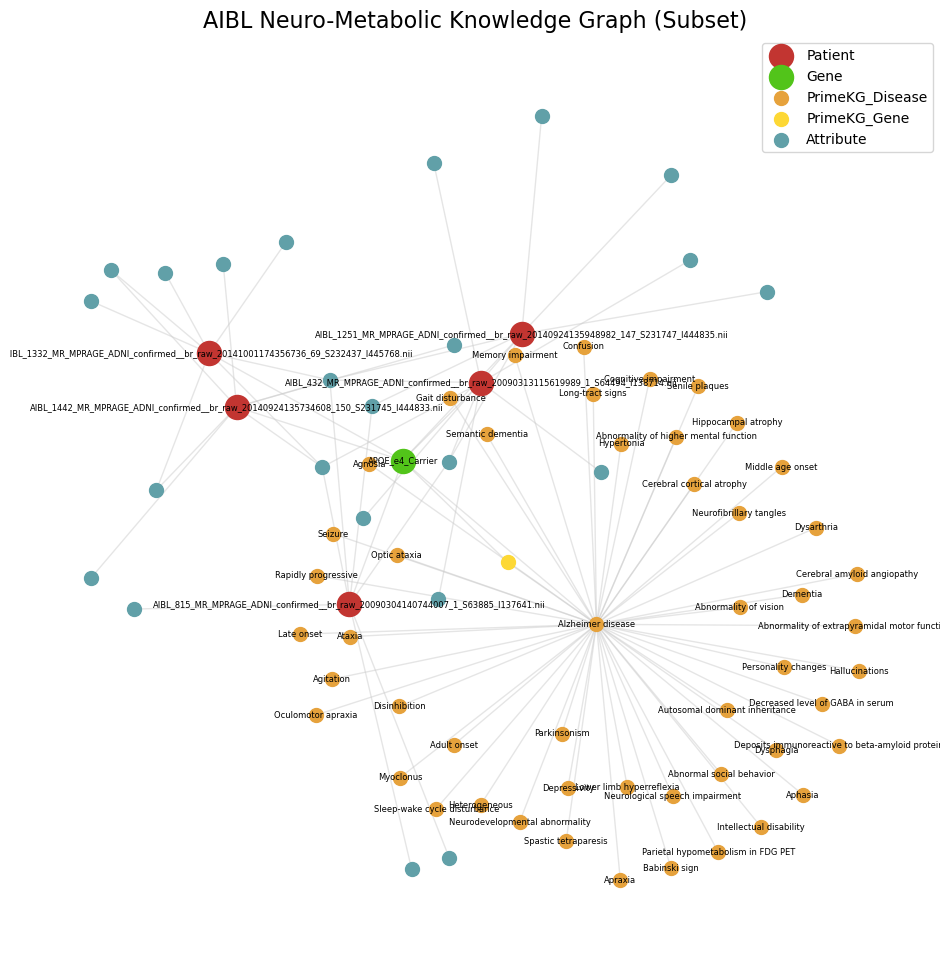

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random

# ================= 配置 =================
TRIPLETS_FILE = 'aibl_knowledge_triplets.csv'
OUTPUT_PDF = "aibl_kg_subset_high_res.pdf"
DPI = 600

# 颜色映射 (Matplotlib 格式)
COLOR_MAP = {
    "Patient": "#c23531", "Gene": "#52c41a", "PrimeKG_Disease": "#e6a23c",
    "PrimeKG_Gene": "#fdd835", "Attribute": "#61a0a8", "Other": "#d48265"
}

def get_category(node):
    if node.startswith("Patient:"): return "Patient"
    if node.startswith("Gene:"): return "Gene"
    if node.startswith("Concept:") or node.startswith("Test:"): return "Attribute"
    if node.startswith("PrimeKG:"):
        name = node.split(":", 1)[1]
        return "PrimeKG_Gene" if " " not in name and name.isupper() and len(name)<10 else "PrimeKG_Disease"
    return "Other"

# 1. 数据筛选 (沿用刚才的 VIP 逻辑)
print("🔍 正在筛选数据 (复刻 VIP 筛选逻辑)...")
df = pd.read_csv(TRIPLETS_FILE).astype(str)
valid_patients = df[df['relation'] == 'has_gene_risk']['head'].unique()

if len(valid_patients) > 0:
    selected_patients = random.sample(list(valid_patients), min(5, len(valid_patients)))
else:
    selected_patients = random.sample(list(df[df['head'].str.startswith("Patient:")]['head'].unique()), 5)

# 构建三层子图
layer1 = df[df['head'].isin(selected_patients)]
gene_nodes = layer1[layer1['tail'].str.startswith("Gene:")]['tail'].unique()
layer2 = df[df['head'].isin(gene_nodes)]
layer3 = df[df['head'].isin(layer2['tail'].unique())].head(50)
subset_df = pd.concat([layer1, layer2, layer3]).drop_duplicates()

# 2. 构建 NetworkX 图
G = nx.Graph()
for _, row in subset_df.iterrows():
    G.add_edge(row['head'], row['tail'])

# 3. 绘图设置
print(f"🎨 正在绘制高分辨率 PDF (DPI={DPI})...")
plt.figure(figsize=(12, 12))  # 画布大小

# 计算布局 (Spring Layout 模拟力导向)
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# 绘制节点
for cat, color in COLOR_MAP.items():
    nodelist = [n for n in G.nodes() if get_category(n) == cat]
    if nodelist:
        # 病人和基因节点画大一点
        size = 300 if cat in ["Patient", "Gene"] else 100
        nx.draw_networkx_nodes(G, pos, nodelist=nodelist, node_color=color, node_size=size, label=cat)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='#cccccc', alpha=0.5, width=1)

# 绘制标签 (只显示 病人 和 基因 的名字，保持 PDF 干净)
labels = {n: n.split(":")[-1] for n in G.nodes() if get_category(n) in ["Patient", "Gene", "PrimeKG_Disease"]}
nx.draw_networkx_labels(G, pos, labels, font_size=6, font_family='sans-serif')

# 添加图例
plt.legend(scatterpoints=1)
plt.axis('off')  # 关闭坐标轴
plt.title("AIBL Neuro-Metabolic Knowledge Graph (Subset)", fontsize=16)

# 4. 保存
plt.savefig(OUTPUT_PDF, format='pdf', dpi=DPI, bbox_inches='tight')
print(f"✅ 高清 PDF 已生成: {OUTPUT_PDF}")